# IMDb Success Analysis & Visualization

This notebook explores the factors that contribute to a title's success on IMDb. We will analyze:
1.  **Distribution of Ratings**: How are ratings spread across all titles?
2.  **Success Metrics**: Comparing popularity (votes) vs. quality (rating).
3.  **Content Type Performance**: Do Movies or TV Series perform better?
4.  **Temporal Trends**: How have ratings and output changed over time?
5.  **Genre Analysis**: Which genres are most successful?

## 1. Dataset Description

### Data source (IMDb official non-commercial dataset)
This project uses the **IMDb Non-Commercial Datasets** (downloadable as `.tsv.gz` from IMDb).  
We work with two files and join them using the unique title identifier **`tconst`**:

1. **`title.basics.tsv`** — title metadata
2. **`title.ratings.tsv`** — user ratings and vote counts

### Unit of analysis
Each row represents a **title** (movie / TV title), identified by `tconst`.

### Key variables used
**From `title.basics.tsv`:**
- `tconst` *(categorical, key)*: unique IMDb title id
- `titleType` *(categorical)*: `movie`, `tvSeries`, `tvMiniSeries`, `tvMovie`, `tvSpecial`, `video`
- `primaryTitle` *(text)*: title name
- `startYear` *(numerical)*: release year (may contain missing/invalid values)
- `genres` *(categorical multi-label)*: comma-separated genres like `"Action,Drama"`

**From `title.ratings.tsv`:**
- `averageRating` *(numerical)*: average rating on a 1–10 scale
- `numVotes` *(numerical)*: number of votes (popularity proxy)

### Why this dataset fits the problem
We want to analyze what makes a title “successful” on IMDb using:
- **Quality proxy:** `averageRating`
- **Popularity proxy:** `numVotes`

### Known limitations (important to mention)
- IMDb uses `\N` to represent missing values in TSV files.
- `startYear` can be missing or invalid (non-numeric strings).
- `genres` is multi-valued; a title can belong to multiple genres.
- Ratings can be noisy when `numVotes` is very small → we often filter by a minimum vote threshold.


## 2. Data Preprocessing

To make the dataset usable for analysis and modeling, we apply the following preprocessing steps:

1. **File path robustness**
   - The notebook may run from `notebooks/`, while TSV files are in the project root.
   - We automatically detect the project root and build correct paths.

2. **Memory-efficient loading**
   - `title.basics.tsv` can be very large, so we load it in **chunks** (e.g., 50,000 rows at a time).

3. **Filter relevant title types**
   - Keep only: `movie`, `tvSeries`, `tvMiniSeries`, `tvMovie`, `tvSpecial`, `video`.

4. **Handle missing / invalid values**
   - Convert `startYear` to numeric (`errors="coerce"`) → invalid years become `NaN`.
   - Replace IMDb missing marker `\N` with `NaN`.

5. **Merge metadata + ratings**
   - Join `title.basics` with `title.ratings` on `tconst`.

6. **Optional modeling preparation**
   - Create `logVotes = log(1 + numVotes)` to reduce skewness for models.
   - Encode categorical variables:
     - One-hot for `titleType`
     - Multi-hot for `genres` (multi-label)

We keep preprocessing transparent and reproducible so every step can be justified in the presentation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
from pathlib import Path

# --- Robust paths (works whether you run the notebook from /notebooks or project root) ---
# This cell fixes the common error: "TSV files not found" when the notebook's working directory is /notebooks.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "title.basics.tsv").exists() else NOTEBOOK_DIR.parent

BASICS_PATH = PROJECT_ROOT / "title.basics.tsv"
RATINGS_PATH = PROJECT_ROOT / "title.ratings.tsv"

print("Notebook working directory:", NOTEBOOK_DIR)
print("Detected project root:", PROJECT_ROOT)
print("Basics TSV exists:", BASICS_PATH.exists(), "->", BASICS_PATH)
print("Ratings TSV exists:", RATINGS_PATH.exists(), "->", RATINGS_PATH)

assert BASICS_PATH.exists() and RATINGS_PATH.exists(), (
    "TSV files not found. Put title.basics.tsv and title.ratings.tsv in the PROJECT_ROOT folder shown above."
)


Notebook working directory: d:\University\Medtech\4th Year\Semester 2\CS434 - Data Analytics\Project\Data 3\imdb-movie-success-analysis-upgraded\notebooks
Detected project root: d:\University\Medtech\4th Year\Semester 2\CS434 - Data Analytics\Project\Data 3\imdb-movie-success-analysis-upgraded
Basics TSV exists: True -> d:\University\Medtech\4th Year\Semester 2\CS434 - Data Analytics\Project\Data 3\imdb-movie-success-analysis-upgraded\title.basics.tsv
Ratings TSV exists: True -> d:\University\Medtech\4th Year\Semester 2\CS434 - Data Analytics\Project\Data 3\imdb-movie-success-analysis-upgraded\title.ratings.tsv


## 1. Load and Prepare Data (Memory Efficient)
**Note:** To prevent memory errors, we load the large dataset in chunks, filter out unwanted types immediately, and then combine the results.

In [3]:
print("Loading data in chunks to save memory...")

# Define types to keep immediately to save RAM
target_types = ['movie', 'tvSeries', 'tvMiniSeries', 'tvMovie', 'tvSpecial', 'video']

# Columns to keep (minimize memory)
cols_to_use = ['tconst', 'titleType', 'startYear', 'genres', 'primaryTitle']

# 1) Load basics in chunks (memory efficient)
chunks = []
try:
    chunk_iterator = pd.read_csv(
        BASICS_PATH,
        sep="\t",
        usecols=cols_to_use,
        chunksize=50000,
        low_memory=False,
        na_values=["\\N"]
    )

    for chunk in chunk_iterator:
        # Filter to relevant title types
        filtered_chunk = chunk[chunk['titleType'].isin(target_types)].copy()

        # Convert startYear to numeric and coerce invalid values to NaN
        filtered_chunk['startYear'] = pd.to_numeric(filtered_chunk['startYear'], errors='coerce')

        chunks.append(filtered_chunk)

    # Combine all the small filtered chunks into one dataframe
    basics = pd.concat(chunks, axis=0)
    print(f"Basics filtered and loaded! Retained {len(basics):,} relevant titles.")

    # Clean up memory
    del chunks

    # 2) Load ratings (smaller file, safe to load at once)
    ratings = pd.read_csv(
        RATINGS_PATH,
        sep="\t",
        low_memory=False,
        na_values=["\\N"]
    )

    # 3) Merge on tconst
    df = pd.merge(basics, ratings, on='tconst')
    print(f"Final merged dataset size: {len(df):,} records.")

    display(df.head())

except FileNotFoundError:
    print("Error: TSV files not found! Please check PROJECT_ROOT and file names.")
except Exception as e:
    print(f"An error occurred: {e}")


Loading data in chunks to save memory...
Basics filtered and loaded! Retained 1,631,541 relevant titles.
Final merged dataset size: 598,759 records.


,tconst,titleType,primaryTitle,startYear,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894.0,Romance,5.3,232
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897.0,"Documentary,News,Sport",5.3,584
2,tt0000335,movie,Soldiers of the Cross,1900.0,"Biography,Drama",5.4,67
3,tt0000502,movie,Bohemios,1905.0,NaN,3.3,25
4,tt0000574,movie,The Story of the Kelly Gang,1906.0,"Action,Adventure,Biography",6.0,1048


In [4]:
# --- Quick inspection (always do this before EDA) ---
print("Columns:", list(df.columns))
print("\nData types:")
display(df.dtypes)

print("\nMissing values (count):")
display(df.isna().sum().sort_values(ascending=False))

print("\nSummary stats (numerical):")
display(df[['startYear','averageRating','numVotes']].describe().T)

# Votes are usually extremely skewed → log transform is helpful for charts/models
df['logVotes'] = np.log1p(df['numVotes'])


Columns: ['tconst', 'titleType', 'primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes']

Data types:


tconst            object
titleType         object
primaryTitle      object
startYear        float64
genres            object
averageRating    float64
numVotes           int64
dtype: object


Missing values (count):


genres           19929
startYear           79
primaryTitle         2
titleType            0
tconst               0
averageRating        0
numVotes             0
dtype: int64


Summary stats (numerical):


,count,mean,std,min,25%,50%,75%,max
startYear,598680.0,2001.332167,22.367773,1894.0,1992.0,2009.0,2018.0,2026.0
averageRating,598759.0,6.421177,1.442745,1.0,5.6,6.5,7.4,10.0
numVotes,598759.0,2479.851760,29836.651779,5.0,17.0,45.0,210.0,3152040.0


## 2. Distribution of Ratings (Histogram)
Let's see the overall spread of ratings. Is it a Bell Curve?
-   **X-Axis**: Average Rating (0-10)
-   **Y-Axis**: Number of Titles

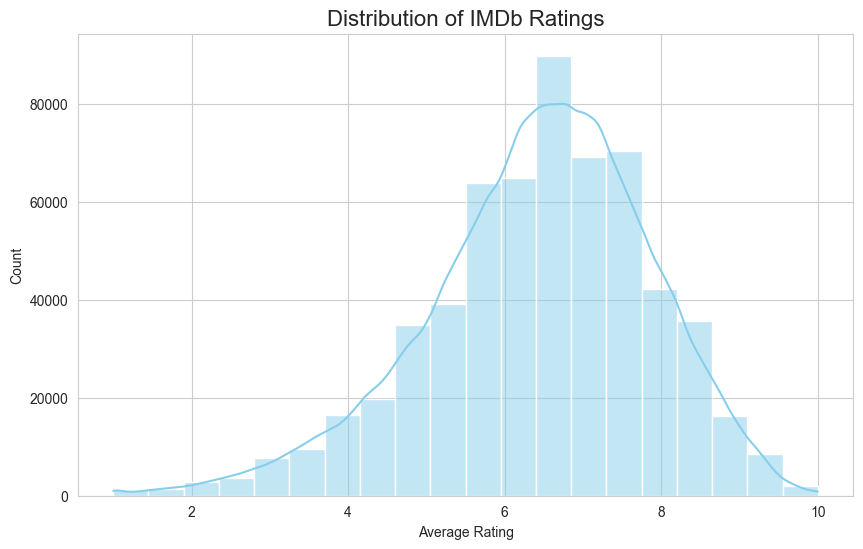

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['averageRating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of IMDb Ratings', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.show()

## 3. Ratings by Content Type (Box Plot)
Which format tends to get higher ratings: Movies or TV Series?
-   **Box**: Represents the middle 50% of data.
-   **Line inside box**: The median rating.
-   **Dots**: Outliers.

C:\Users\khali\AppData\Local\Temp\ipykernel_44260\2861648141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='titleType', y='averageRating', data=df, palette='Set3')


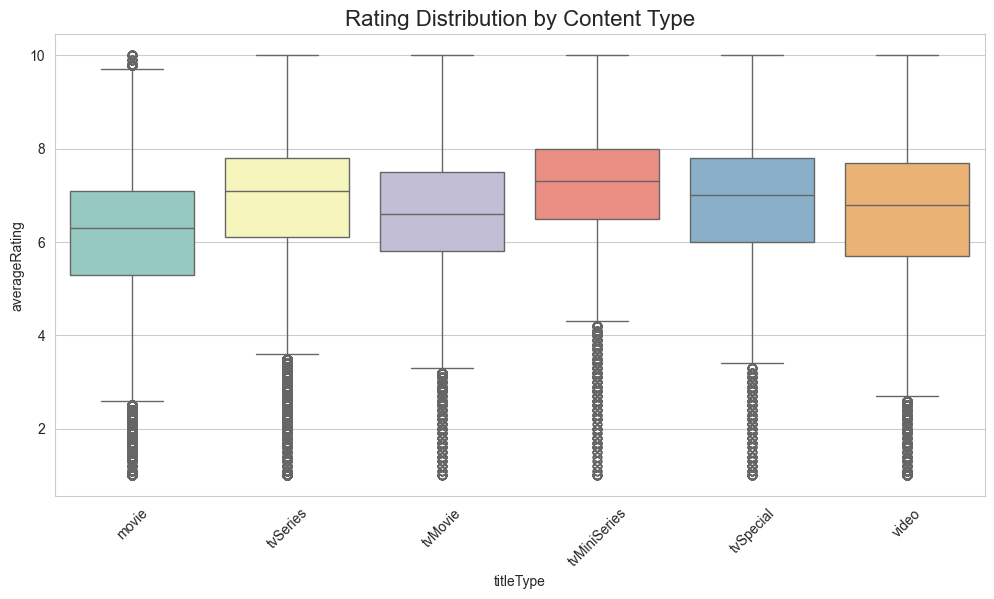

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='titleType', y='averageRating', data=df, palette='Set3')
plt.title('Rating Distribution by Content Type', fontsize=16)
plt.xticks(rotation=45)
plt.show()

## 4. Popularity vs. Quality (Scatter Plot)
Do popular movies (more votes) always have higher ratings?
-   **X-Axis**: Number of Votes (Log Scale - to handle massive outliers like *The Shawshank Redemption*)
-   **Y-Axis**: Average Rating
-   **Opacity**: Used to see density in overlapping points.

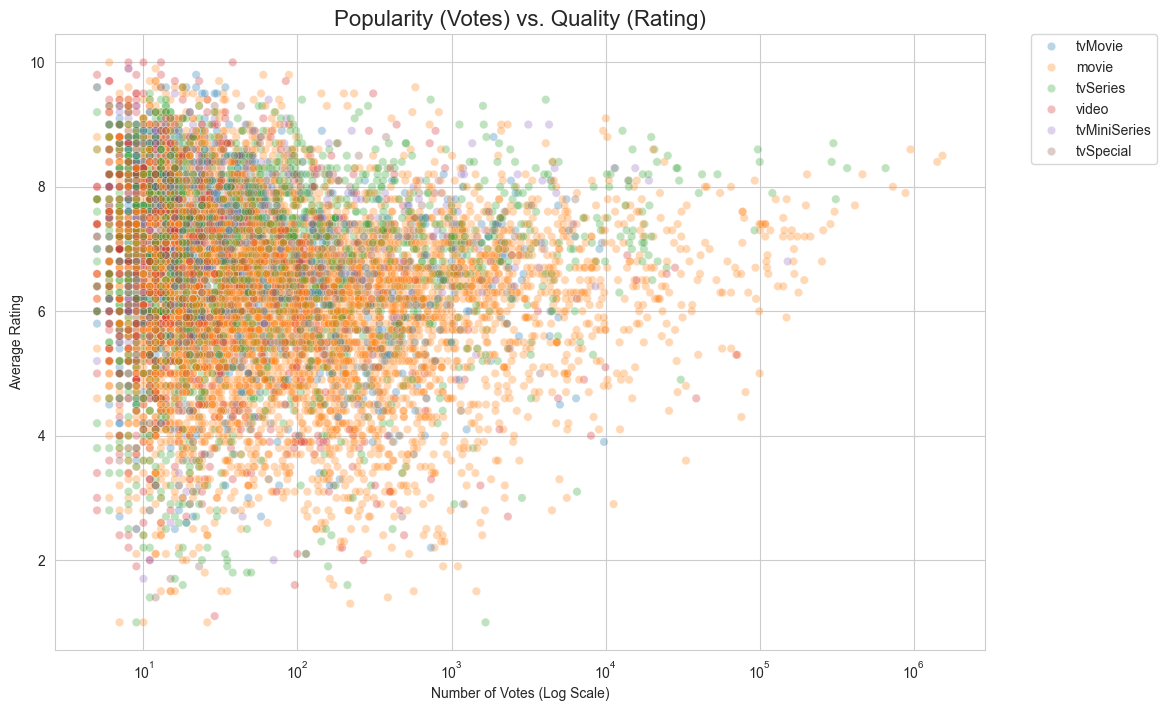

In [7]:
plt.figure(figsize=(12, 8))
# Sample 10,000 points if dataset is too large, for faster plotting
sample_df = df.sample(n=min(10000, len(df)), random_state=42)

sns.scatterplot(x='numVotes', y='averageRating', data=sample_df, alpha=0.3, hue='titleType')
plt.xscale('log') # Log scale because vote counts vary wildly (10 vs 1,000,000)
plt.title('Popularity (Votes) vs. Quality (Rating)', fontsize=16)
plt.xlabel('Number of Votes (Log Scale)')
plt.ylabel('Average Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

## 4b. Correlation Analysis (Numeric Features)

Correlation helps quantify relationships between numeric variables like:
- `averageRating`
- `numVotes` / `logVotes`
- `startYear`

Because `numVotes` is highly skewed, we also include `logVotes`.


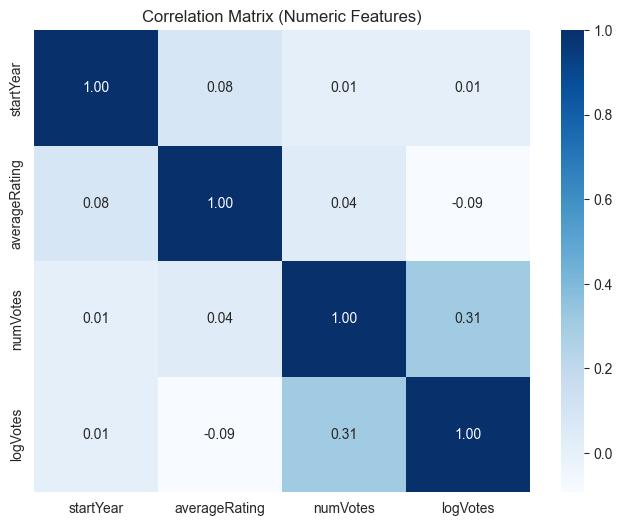

In [8]:
# Correlation matrix on numeric features
num_cols = ['startYear', 'averageRating', 'numVotes', 'logVotes']
corr = df[num_cols].dropna().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


## 5. Success Over Time (Line Chart)
Are movies getting better or worse over time? Let's check the average rating per year.

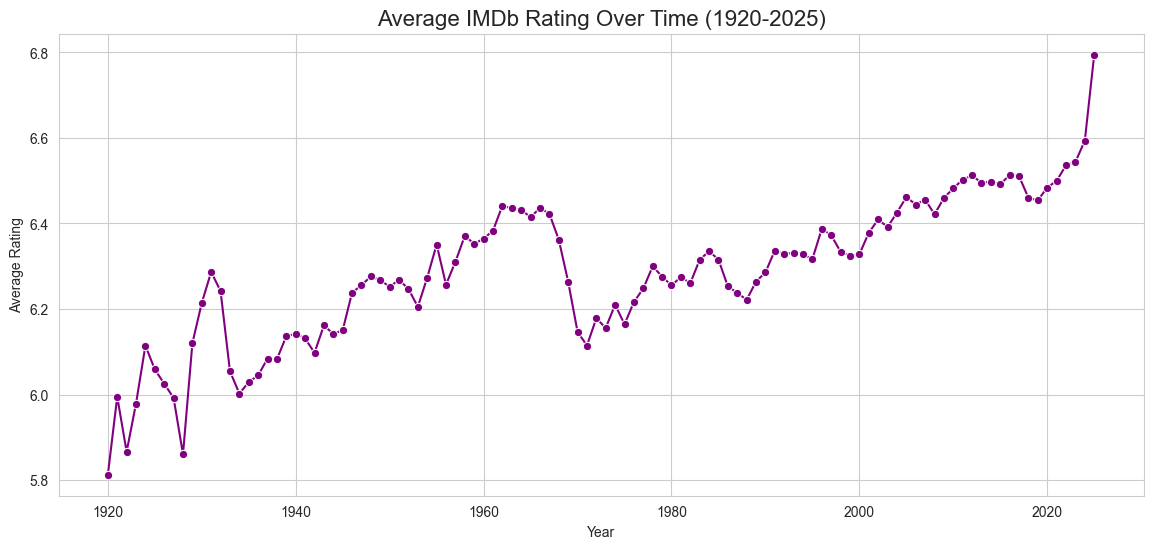

In [9]:
# Filter weird years (future dates or very old errors)
year_df = df[(df['startYear'] >= 1920) & (df['startYear'] <= 2025)]

# Group by year and calculate mean rating
yearly_ratings = year_df.groupby('startYear')['averageRating'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x='startYear', y='averageRating', data=yearly_ratings, marker='o', color='purple')
plt.title('Average IMDb Rating Over Time (1920-2025)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

## 6. Top Genres (Bar Chart)
Which genres have the highest average ratings? Note: Movies can have multiple genres (e.g., "Action,Adventure"), so we need to split them first.

C:\Users\khali\AppData\Local\Temp\ipykernel_44260\2760391352.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_rating', y='genres', data=genre_stats.head(20), palette='viridis')


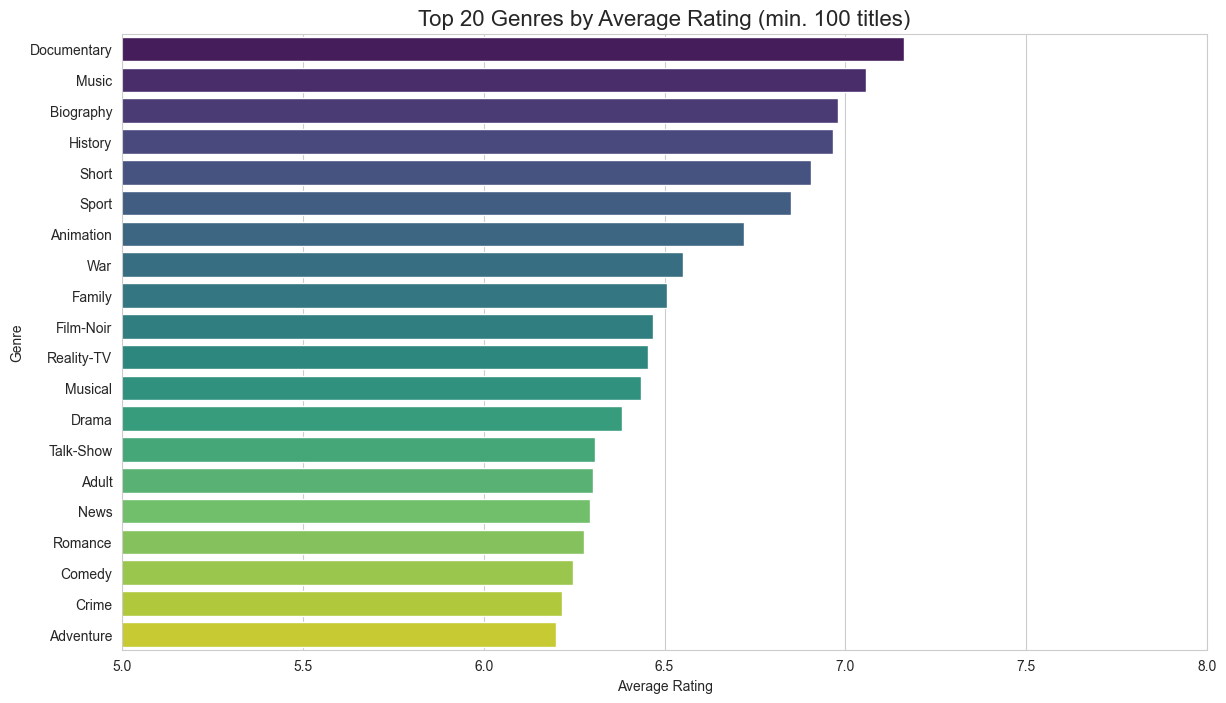

In [10]:
# Drop rows with missing genres
genre_df = df.dropna(subset=['genres']).copy()

# Split genres string 'Action,Adventure' into list ['Action', 'Adventure']
genre_df['genres'] = genre_df['genres'].str.split(',')

# Explode the list so each genre gets its own row
genre_exploded = genre_df.explode('genres')

# Calculate stats per genre
genre_stats = genre_exploded.groupby('genres').agg(
    avg_rating=('averageRating', 'mean'),
    count=('tconst', 'count')
).reset_index()

# Filter for genres with at least 100 titles to be statistically significant
genre_stats = genre_stats[genre_stats['count'] > 100].sort_values(by='avg_rating', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='avg_rating', y='genres', data=genre_stats.head(20), palette='viridis')
plt.title('Top 20 Genres by Average Rating (min. 100 titles)', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(5, 8) # Zoom in on the relevant rating range
plt.show()

## 4. Modeling Approach (Classification)

### Goal
Predict whether a title is **successful** on IMDb.

### Problem type
**Binary classification** (Success = 1, Not success = 0)

### Target (Success Label)
We define success using **both quality and popularity**:
- `averageRating ≥ RATING_THRESHOLD`
- `numVotes ≥ VOTES_THRESHOLD`

This is a practical, explainable definition for a “midway” project.

### Features used
- `startYear` (numerical)
- `logVotes = log(1 + numVotes)` (numerical, reduces skew)
- `titleType` (categorical → one-hot encoded)
- `genres` (multi-label → multi-hot encoded using `MultiLabelBinarizer`)

### Models
We train and compare:
1. **Logistic Regression** (baseline, interpretable)
2. **Random Forest** (non-linear, handles interactions)

### Evaluation (what we report)
- Accuracy
- Precision / Recall / F1-score
- ROC AUC (when both classes are present in test set)
- Confusion matrix
- Feature importance (Random Forest)

We also check **class imbalance** because “success” may be rare.


Success label distribution:


success
Not success    591426
Success          7254
Name: count, dtype: int64

Success rate: 1.21 %
Feature matrix shape: (598680, 37)


,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,Random Forest,0.993778,0.754323,0.721571,0.737584,0.996714
1,Logistic Regression,0.978010,0.355218,0.999311,0.524128,0.995024
0,Dummy (most_frequent),0.987882,0.000000,0.000000,0.000000,0.500000



Best model: Random Forest

Classification report (best model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    118285
           1       0.75      0.72      0.74      1451

    accuracy                           0.99    119736
   macro avg       0.88      0.86      0.87    119736
weighted avg       0.99      0.99      0.99    119736



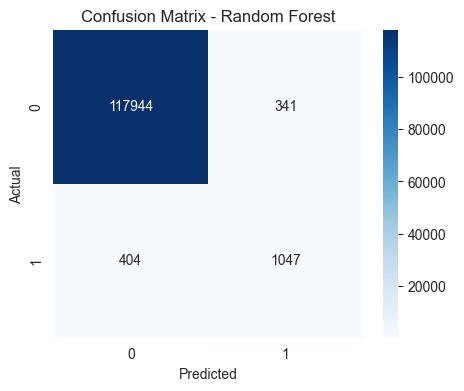

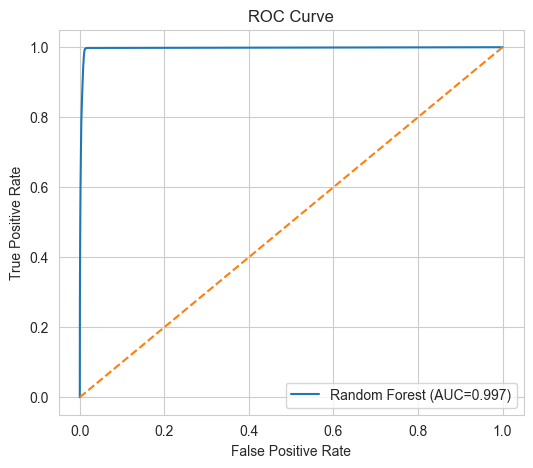

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.preprocessing import MultiLabelBinarizer

# -----------------------------
# 1) Define "success" label
# -----------------------------
RATING_THRESHOLD = 7.0
VOTES_THRESHOLD = 10_000

model_df = df.dropna(subset=['averageRating', 'numVotes', 'startYear']).copy()
model_df['success'] = ((model_df['averageRating'] >= RATING_THRESHOLD) & (model_df['numVotes'] >= VOTES_THRESHOLD)).astype(int)

print("Success label distribution:")
display(model_df['success'].value_counts().rename({0:"Not success", 1:"Success"}))
print("Success rate:", round(model_df['success'].mean() * 100, 2), "%")

# -----------------------------
# 2) Feature engineering
# -----------------------------
model_df['logVotes'] = np.log1p(model_df['numVotes'])

# Title type (one-hot)
type_ohe = pd.get_dummies(model_df['titleType'].fillna("unknown"), prefix="type")

# Genres (multi-label -> multi-hot)
genres_clean = model_df['genres'].fillna("\\N").replace({"\\N": "Unknown"})
genres_list = genres_clean.astype(str).apply(lambda s: [g.strip() for g in s.split(",") if g.strip()])

mlb = MultiLabelBinarizer()
genre_ohe = pd.DataFrame(
    mlb.fit_transform(genres_list),
    columns=[f"genre__{g}" for g in mlb.classes_],
    index=model_df.index
)

# Final feature matrix
X = pd.concat([
    model_df[['startYear', 'logVotes']].astype(float),
    type_ohe,
    genre_ohe
], axis=1)

y = model_df['success'].astype(int)

print("Feature matrix shape:", X.shape)

# -----------------------------
# 3) Train/Test split
# -----------------------------
# stratify keeps class proportions similar in train/test if both classes exist
strat = y if y.nunique() == 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strat
)

# -----------------------------
# 4) Train models
# -----------------------------
models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=None),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model

    y_pred = model.predict(X_test)

    # Some models provide probabilities; needed for ROC AUC
    if hasattr(model, "predict_proba") and y_test.nunique() == 2:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
display(results_df)

# -----------------------------
# 5) Diagnostics for best model
# -----------------------------
best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]

print("\nBest model:", best_name)

y_pred_best = best_model.predict(X_test)
print("\nClassification report (best model):")
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve (only if probabilities available)
if hasattr(best_model, "predict_proba") and y_test.nunique() == 2:
    y_proba_best = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_best)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{best_name} (AUC={roc_auc_score(y_test, y_proba_best):.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


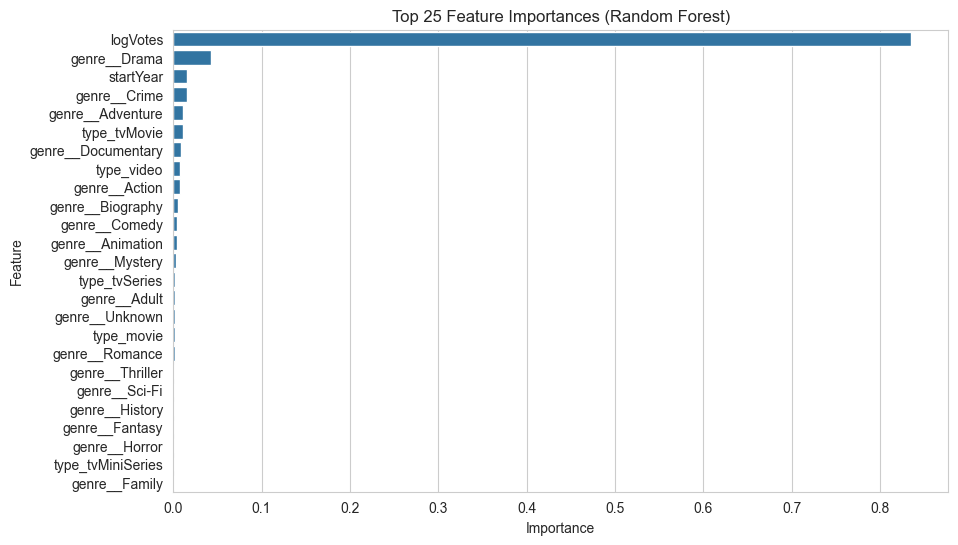

In [12]:
# -----------------------------
# 6) Feature importance (Random Forest)
# -----------------------------
rf_model = trained.get("Random Forest", None)
if rf_model is not None:
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    top_n = 25
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index)
    plt.title(f"Top {top_n} Feature Importances (Random Forest)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("Random Forest model not available.")
